# 🚆 Deutsche Bahn – Verspätungsprognose
## Fallstudie: Machine Learning für die Deutsche Bahn AG
**Forschungsfrage:** Kann die Ankunftsverspätung eines Zuges (in Minuten) anhand von Strecke, Zugkategorie, Bundesland, Uhrzeit und Wochentag vorhergesagt werden?

**ML-Typ:** Supervised Learning – Regression

**Datensatz:** Deutsche Bahn (DB) Delays – Kaggle (nokkyu/deutsche-bahn-db-delays), 12%-Stichprobe (247.363 Zeilen)

---
### Aufbau des Notebooks
1. Daten laden & erkunden
2. Datenbereinigung
3. Feature Engineering
4. Encoding & Train/Test Split
5. Modellbildung (mehrere Regressionsmodelle)
6. Evaluation & Modellvergleich
7. Deployment-Demo

## 1. Bibliotheken importieren

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print('Bibliotheken erfolgreich geladen.')

Bibliotheken erfolgreich geladen.


## 2. Datensatz laden

In [2]:
df = pd.read_csv('db_delays_sample.csv')

print(f'Datensatz geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten')
df.head()

Datensatz geladen: 247363 Zeilen, 16 Spalten


,line,category,station,state,city,zip,long,lat,arrival_plan,departure_plan,arrival_change,departure_change,arrival_delay_m,departure_delay_m,arrival_delay_check,departure_delay_check
0,3,5,Leipzig-Wahren,Sachsen,Leipzig-Wahren,4159,12.321483,51.380687,2024-07-08 11:13:00,2024-07-08 11:13:00,2024-07-08 11:13:00,2024-07-08 11:14:00,0,1,on_time,on_time
1,24,1,Köln Hbf,Nordrhein-Westfalen,Köln,50667,6.958729,50.943030,2024-07-08 08:43:00,2024-07-08 08:46:00,NaN,NaN,0,0,on_time,on_time
2,3,5,Germersheim Mitte/Rhein,Rheinland-Pfalz,Germersheim,76726,8.379305,49.219876,2024-07-08 13:44:00,2024-07-08 13:44:00,2024-07-08 13:44:00,2024-07-08 13:45:00,0,1,on_time,on_time
3,8,2,Berlin Zoologischer Garten,Berlin,Berlin,10623,13.332445,52.507341,2024-07-08 08:25:00,2024-07-08 08:26:00,2024-07-08 08:28:00,2024-07-08 08:29:00,3,3,on_time,on_time
4,8,4,Bergfelde (b Berlin),Brandenburg,Hohen Neuendorf,16562,13.320244,52.670303,2024-07-08 06:27:00,2024-07-08 06:27:00,2024-07-08 06:27:00,2024-07-08 06:27:00,0,0,on_time,on_time


## 3. Erste Datenerkundung

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247363 entries, 0 to 247362
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   line                   247363 non-null  object 
 1   category               247363 non-null  int64  
 2   station                247363 non-null  object 
 3   state                  247363 non-null  object 
 4   city                   247363 non-null  object 
 5   zip                    247363 non-null  int64  
 6   long                   247363 non-null  float64
 7   lat                    247363 non-null  float64
 8   arrival_plan           222159 non-null  object 
 9   departure_plan         247363 non-null  object 
 10  arrival_change         190309 non-null  object 
 11  departure_change       206566 non-null  object 
 12  arrival_delay_m        247363 non-null  int64  
 13  departure_delay_m      247363 non-null  int64  
 14  arrival_delay_check    247363 non-nu

In [4]:
df.describe()

,category,zip,long,lat,arrival_delay_m,departure_delay_m
count,247363.000000,247363.000000,247363.000000,247363.000000,247363.000000,247363.000000
mean,3.872754,46112.470875,10.188528,50.892518,1.175920,1.223174
std,1.036195,28227.369426,2.280008,1.788774,3.381593,3.385075
min,1.000000,1067.000000,6.070715,47.411032,0.000000,0.000000
25%,3.000000,18069.000000,8.490630,49.379831,0.000000,0.000000
50%,4.000000,46535.000000,9.944088,51.102677,0.000000,0.000000
75%,5.000000,70736.000000,12.107890,52.479377,1.000000,1.000000
max,5.000000,99974.000000,14.979080,54.906839,113.000000,113.000000


In [5]:
# Fehlende Werte
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Anzahl': missing, 'Prozent': missing_pct})
print(missing_df[missing_df['Anzahl'] > 0])

                  Anzahl  Prozent
arrival_plan       25204    10.19
arrival_change     57054    23.06
departure_change   40797    16.49


## 4. Explorative Datenanalyse (EDA)

=== Statistik Ankunftsverspätung (Minuten) ===
count    247363.000000
mean          1.175920
std           3.381593
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         113.000000
Name: arrival_delay_m, dtype: float64


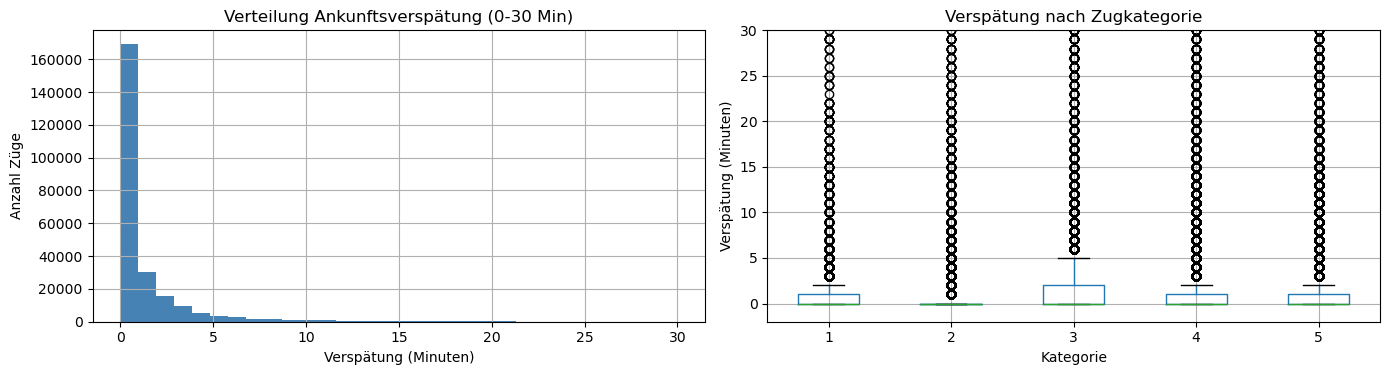

In [6]:
# Verteilung der Zielvariable (Ankunftsverspätung)
print('=== Statistik Ankunftsverspätung (Minuten) ===')
print(df['arrival_delay_m'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramm (begrenzt auf 0-30 Min für Lesbarkeit)
df[df['arrival_delay_m'] <= 30]['arrival_delay_m'].hist(bins=31, ax=axes[0], color='steelblue')
axes[0].set_title('Verteilung Ankunftsverspätung (0-30 Min)')
axes[0].set_xlabel('Verspätung (Minuten)')
axes[0].set_ylabel('Anzahl Züge')

# Boxplot nach Zugkategorie
df.boxplot(column='arrival_delay_m', by='category', ax=axes[1])
axes[1].set_title('Verspätung nach Zugkategorie')
axes[1].set_xlabel('Kategorie')
axes[1].set_ylabel('Verspätung (Minuten)')
axes[1].set_ylim(-2, 30)
plt.suptitle('')

plt.tight_layout()
plt.show()

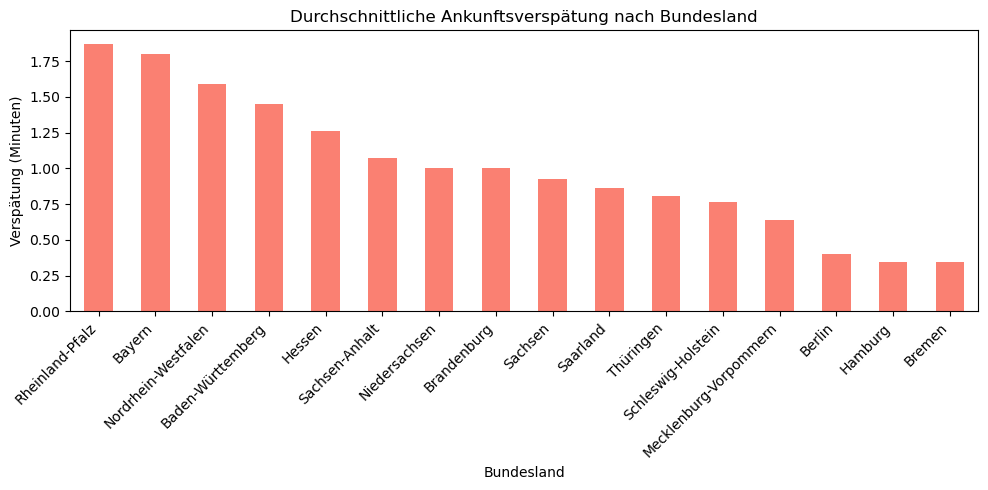

In [7]:
# Durchschnittliche Verspätung nach Bundesland
delay_by_state = df.groupby('state')['arrival_delay_m'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
delay_by_state.plot(kind='bar', color='salmon')
plt.title('Durchschnittliche Ankunftsverspätung nach Bundesland')
plt.ylabel('Verspätung (Minuten)')
plt.xlabel('Bundesland')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Datenbereinigung

In [8]:
df_clean = df.copy()

# Zeilen ohne arrival_plan können wir keine Uhrzeit/Wochentag entnehmen -> entfernen
vor = len(df_clean)
df_clean = df_clean.dropna(subset=['arrival_plan'])
print(f'Zeilen ohne arrival_plan entfernt: {vor - len(df_clean)}')

# Extreme Ausreißer begrenzen (Verspätungen > 120 Min sind seltene Sonderfälle, z.B. Zugausfälle)
vor = len(df_clean)
df_clean = df_clean[df_clean['arrival_delay_m'] <= 120]
print(f'Extreme Ausreißer (>120 Min) entfernt: {vor - len(df_clean)}')

print(f'\nVerbleibende Zeilen: {len(df_clean)}')

Zeilen ohne arrival_plan entfernt: 25204
Extreme Ausreißer (>120 Min) entfernt: 0

Verbleibende Zeilen: 222159


## 6. Feature Engineering
Aus dem geplanten Ankunftszeitpunkt (`arrival_plan`) extrahieren wir zeitliche Merkmale, die typischerweise mit Verspätungen zusammenhängen: Tageszeit (Rushhour?), Wochentag (Wochenende?).

In [9]:
# Datum/Uhrzeit parsen
df_clean['arrival_plan'] = pd.to_datetime(df_clean['arrival_plan'])

# Stunde des Tages (0-23)
df_clean['hour'] = df_clean['arrival_plan'].dt.hour

# Wochentag (0=Montag, 6=Sonntag)
df_clean['weekday'] = df_clean['arrival_plan'].dt.weekday

# Wochenende?
df_clean['is_weekend'] = (df_clean['weekday'] >= 5).astype(int)

# Rushhour? (7-9 Uhr und 16-18 Uhr typische Pendlerzeiten)
df_clean['is_rushhour'] = df_clean['hour'].isin([7, 8, 16, 17, 18]).astype(int)

print('Neue Features erstellt: hour, weekday, is_weekend, is_rushhour')
df_clean[['arrival_plan', 'hour', 'weekday', 'is_weekend', 'is_rushhour']].head()

Neue Features erstellt: hour, weekday, is_weekend, is_rushhour


,arrival_plan,hour,weekday,is_weekend,is_rushhour
0,2024-07-08 11:13:00,11,0,0,0
1,2024-07-08 08:43:00,8,0,0,1
2,2024-07-08 13:44:00,13,0,0,0
3,2024-07-08 08:25:00,8,0,0,1
4,2024-07-08 06:27:00,6,0,0,0


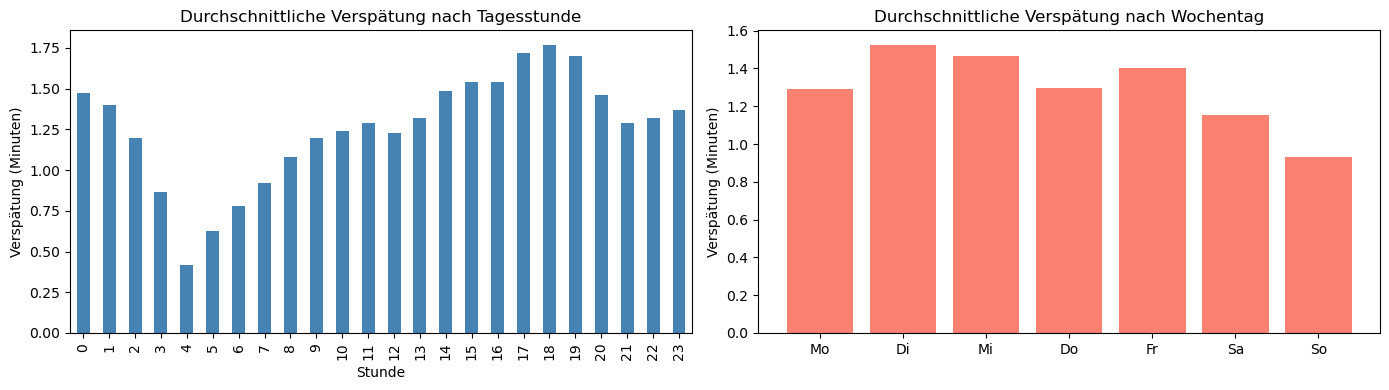

In [10]:
# Visualisierung: Verspätung nach Stunde und Wochentag
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clean.groupby('hour')['arrival_delay_m'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Durchschnittliche Verspätung nach Tagesstunde')
axes[0].set_xlabel('Stunde')
axes[0].set_ylabel('Verspätung (Minuten)')

weekday_names = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']
delay_by_wd = df_clean.groupby('weekday')['arrival_delay_m'].mean()
axes[1].bar(weekday_names, delay_by_wd.values, color='salmon')
axes[1].set_title('Durchschnittliche Verspätung nach Wochentag')
axes[1].set_ylabel('Verspätung (Minuten)')

plt.tight_layout()
plt.show()

In [11]:
# Relevante Spalten für das Modell auswählen
# Hinweis: 'station' (1995 Werte) und 'line' (289 Werte, gemischt numerisch/alphanumerisch wie 'RB75')
# sind zu granular für One-Hot-Encoding -> 'category' und 'state' fassen diese Information sinnvoll zusammen.
# 'station' behalten wir trotzdem, um daraus ein Lag-Feature (Stations-Historie) abzuleiten.
model_cols = ['category', 'state', 'station', 'hour', 'weekday', 'is_weekend', 
              'is_rushhour', 'lat', 'long', 'arrival_delay_m']

df_model = df_clean[model_cols].copy()
print(f'Finaler Modell-Datensatz: {df_model.shape}')
df_model.head()

Finaler Modell-Datensatz: (222159, 10)


,category,state,station,hour,weekday,is_weekend,is_rushhour,lat,long,arrival_delay_m
0,5,Sachsen,Leipzig-Wahren,11,0,0,0,51.380687,12.321483,0
1,1,Nordrhein-Westfalen,Köln Hbf,8,0,0,1,50.943030,6.958729,0
2,5,Rheinland-Pfalz,Germersheim Mitte/Rhein,13,0,0,0,49.219876,8.379305,0
3,2,Berlin,Berlin Zoologischer Garten,8,0,0,1,52.507341,13.332445,3
4,4,Brandenburg,Bergfelde (b Berlin),6,0,0,0,52.670303,13.320244,0


## 7. Encoding kategorischer Variablen

In [12]:
# 'category' ist bereits numerisch (1-5), 'state' muss One-Hot-encodiert werden
# 'station' bleibt vorerst als Bahnhofs-Identifier erhalten (wird für das Lag-Feature nach dem Split gebraucht)
df_encoded = pd.get_dummies(df_model, columns=['state'], drop_first=True)

print(f'Spalten nach Encoding: {df_encoded.shape[1]}')
df_encoded.head()

Spalten nach Encoding: 24


,category,station,hour,weekday,is_weekend,is_rushhour,lat,long,arrival_delay_m,state_Bayern,state_Berlin,state_Brandenburg,state_Bremen,state_Hamburg,state_Hessen,state_Mecklenburg-Vorpommern,state_Niedersachsen,state_Nordrhein-Westfalen,state_Rheinland-Pfalz,state_Saarland,state_Sachsen,state_Sachsen-Anhalt,state_Schleswig-Holstein,state_Thüringen
0,5,Leipzig-Wahren,11,0,0,0,51.380687,12.321483,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,1,Köln Hbf,8,0,0,1,50.943030,6.958729,0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,5,Germersheim Mitte/Rhein,13,0,0,0,49.219876,8.379305,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,2,Berlin Zoologischer Garten,8,0,0,1,52.507341,13.332445,3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,4,Bergfelde (b Berlin),6,0,0,0,52.670303,13.320244,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


## 8. Train/Test Split

In [13]:
X = df_encoded.drop(columns=['arrival_delay_m'])
y = df_encoded['arrival_delay_m']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Trainingsdaten: {X_train.shape[0]} Zeilen')
print(f'Testdaten:      {X_test.shape[0]} Zeilen')
print(f'Anzahl Features (vor Lag-Feature): {X_train.shape[1]}')

Trainingsdaten: 177727 Zeilen
Testdaten:      44432 Zeilen
Anzahl Features (vor Lag-Feature): 23


### 8.1 Lag-Feature: Historische Stationsverspätung
Wir berechnen die durchschnittliche Verspätung je Bahnhof **ausschließlich aus den Trainingsdaten** und übertragen diesen Wert anschließend auf die Testdaten. So vermeiden wir Data Leakage (Informationen aus den Testdaten dürften nicht in die Modellbildung einfließen).

In [14]:
# Durchschnittliche Verspätung je Bahnhof - NUR aus Trainingsdaten berechnet
station_avg_delay_train = y_train.groupby(X_train['station']).mean()
global_avg_delay = y_train.mean()  # Fallback für unbekannte Bahnhöfe im Testset

X_train = X_train.copy()
X_test = X_test.copy()
X_train['station_avg_delay'] = X_train['station'].map(station_avg_delay_train)
X_test['station_avg_delay'] = X_test['station'].map(station_avg_delay_train).fillna(global_avg_delay)

# 'station' selbst jetzt entfernen (zu viele eindeutige Werte, Information steckt jetzt in station_avg_delay)
X_train = X_train.drop(columns=['station'])
X_test = X_test.drop(columns=['station'])

print(f'Lag-Feature "station_avg_delay" hinzugefügt.')
print(f'Finale Anzahl Features: {X_train.shape[1]}')
X_train.head()

Lag-Feature "station_avg_delay" hinzugefügt.
Finale Anzahl Features: 23


,category,hour,weekday,is_weekend,is_rushhour,lat,long,state_Bayern,state_Berlin,state_Brandenburg,state_Bremen,state_Hamburg,state_Hessen,state_Mecklenburg-Vorpommern,state_Niedersachsen,state_Nordrhein-Westfalen,state_Rheinland-Pfalz,state_Saarland,state_Sachsen,state_Sachsen-Anhalt,state_Schleswig-Holstein,state_Thüringen,station_avg_delay
173816,4,21,4,0,0,52.512093,13.588940,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,0.371728
22098,5,0,0,0,0,48.071068,11.530945,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.729167
55165,5,15,1,0,0,50.657876,7.210214,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,2.561404
242215,3,19,6,1,0,48.144371,11.503669,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2.735099
133980,5,10,3,0,0,48.790017,8.959550,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2.113821


In [15]:
# Skalierung (wichtig für Lineare Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Daten erfolgreich skaliert.')

Daten erfolgreich skaliert.


## 9. Modellbildung
Wir vergleichen drei Regressionsmodelle unterschiedlicher Komplexität.

### 9.1 Lineare Regression (Baseline)

In [16]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print('=== Lineare Regression ===')
print(f'MAE:  {mae_lr:.2f} Minuten')
print(f'RMSE: {rmse_lr:.2f} Minuten')
print(f'R²:   {r2_lr:.3f}')

=== Lineare Regression ===
MAE:  1.63 Minuten
RMSE: 3.55 Minuten
R²:   0.060


### 9.2 Decision Tree Regressor

In [17]:
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print('=== Decision Tree Regressor ===')
print(f'MAE:  {mae_dt:.2f} Minuten')
print(f'RMSE: {rmse_dt:.2f} Minuten')
print(f'R²:   {r2_dt:.3f}')

=== Decision Tree Regressor ===
MAE:  1.62 Minuten
RMSE: 3.56 Minuten
R²:   0.053


### 9.3 Random Forest Regressor (mit Hyperparameter-Tuning)
Statt feste Parameter zu raten, nutzen wir **GridSearchCV**, um eine gute Kombination aus `n_estimators` und `max_depth` systematisch zu finden. Da GridSearch auf dem vollen Trainingsdatensatz (177.727 Zeilen) sehr lange dauern würde, führen wir die Suche auf einer **10%-Stichprobe der Trainingsdaten** durch - ein gängiges Vorgehen, um Rechenzeit zu sparen, ohne die Tuning-Qualität wesentlich zu beeinträchtigen. Das final beste Modell wird anschließend auf dem vollständigen Trainingsdatensatz trainiert.

In [18]:
from sklearn.model_selection import GridSearchCV

# Kleines Suchgitter, 2-fache CV, auf einer Stichprobe - hält die Laufzeit praktikabel
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15]
}

X_train_gs = X_train.sample(frac=0.1, random_state=42)
y_train_gs = y_train.loc[X_train_gs.index]

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_base, param_grid, cv=2, 
    scoring='neg_mean_absolute_error', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_gs, y_train_gs)

print('Beste Parameter (gefunden auf Stichprobe):', grid_search.best_params_)

# Finales Modell mit besten Parametern auf VOLLEM Trainingsdatensatz trainieren
rf = RandomForestRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print()
print('=== Random Forest Regressor (getuned) ===')
print(f'MAE:  {mae_rf:.2f} Minuten')
print(f'RMSE: {rmse_rf:.2f} Minuten')
print(f'R²:   {r2_rf:.3f}')

Beste Parameter (gefunden auf Stichprobe): {'max_depth': 10, 'n_estimators': 100}

=== Random Forest Regressor (getuned) ===
MAE:  1.61 Minuten
RMSE: 3.53 Minuten
R²:   0.073


## 10. Modellvergleich & Evaluation

            Modell  MAE (Min)  RMSE (Min)    R²
Lineare Regression      1.634       3.550 0.060
     Decision Tree      1.620       3.563 0.053
     Random Forest      1.608       3.525 0.073


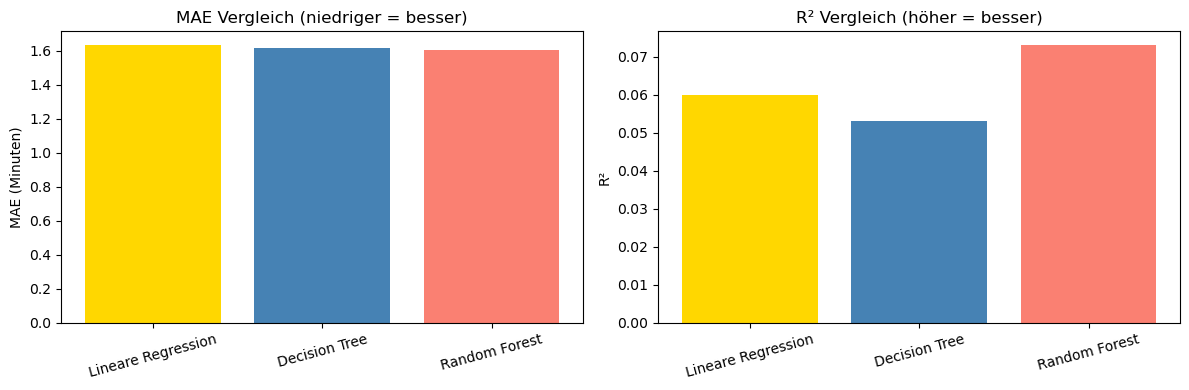


Bestes Modell (niedrigster MAE): Random Forest


In [19]:
results = pd.DataFrame({
    'Modell': ['Lineare Regression', 'Decision Tree', 'Random Forest'],
    'MAE (Min)': [mae_lr, mae_dt, mae_rf],
    'RMSE (Min)': [rmse_lr, rmse_dt, rmse_rf],
    'R²': [r2_lr, r2_dt, r2_rf]
}).round(3)

print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(results['Modell'], results['MAE (Min)'], color=['gold', 'steelblue', 'salmon'])
axes[0].set_title('MAE Vergleich (niedriger = besser)')
axes[0].set_ylabel('MAE (Minuten)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results['Modell'], results['R²'], color=['gold', 'steelblue', 'salmon'])
axes[1].set_title('R² Vergleich (höher = besser)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

bestes_modell = results.sort_values('MAE (Min)').iloc[0]['Modell']
print(f'\nBestes Modell (niedrigster MAE): {bestes_modell}')

### 10.1 Interpretation: Warum ist das R² so niedrig?

Das R² liegt trotz Tuning und Lag-Feature weiterhin in einem niedrigen Bereich. Das ist **inhaltlich nachvollziehbar und kein Modellierungsfehler**, sondern eine Eigenschaft der Daten und des Anwendungsfalls:

1. **Stark schiefe Zielvariable:** Die meisten Züge sind pünktlich oder nur 0-1 Minuten verspätet (siehe Median in Kapitel 4). Wenige Ausreißer mit hoher Verspätung sind statistisch schwer vorherzusagen, dominieren aber die Varianz, die R² misst.
2. **Fehlende Kausalfaktoren im Datensatz:** Die eigentlichen Ursachen von Verspätungen - Wetterereignisse, technische Störungen, Signalausfälle, Bauarbeiten, oder Verspätungen vorausfahrender Züge - sind im verwendeten Datensatz nicht enthalten. Unsere Features (Ort, Uhrzeit, Wochentag, Zugkategorie) sind nur **indirekte Proxy-Variablen**.
3. **MAE ist hier aussagekräftiger als R²:** Ein MAE von ca. 1,6 Minuten bedeutet, dass das Modell im Durchschnitt nur ±1,6 Minuten von der tatsächlichen Verspätung abweicht - das ist für eine praktische Anwendung (z.B. Reiseplanung) durchaus brauchbar, auch wenn R² niedrig bleibt.

**Für die Hausarbeit (Kapitel 7, Evaluation):** Dieser Punkt sollte explizit diskutiert werden. Ein niedriges R² ist hier kein Zeichen für ein schlechtes Modell, sondern zeigt die **Grenzen des verfügbaren Datensatzes** auf. Eine sinnvolle Erweiterung wären externe Daten wie Wetterdaten oder Echtzeit-Streckenauslastung (siehe Kapitel 9 - Ausblick).

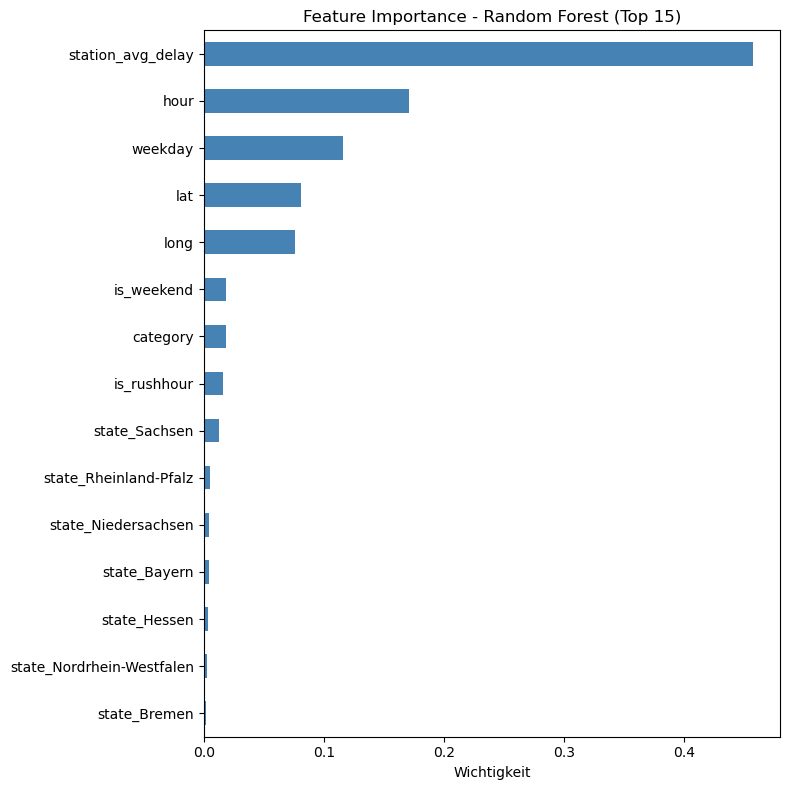

Die 5 wichtigsten Einflussfaktoren auf die Verspätung:
station_avg_delay    0.456815
hour                 0.171156
weekday              0.115644
lat                  0.081356
long                 0.076303
dtype: float64


In [20]:
# Feature Importance (Random Forest) - zeigt welche Faktoren am wichtigsten sind
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importances.tail(15).plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest (Top 15)')
plt.xlabel('Wichtigkeit')
plt.tight_layout()
plt.show()

print('Die 5 wichtigsten Einflussfaktoren auf die Verspätung:')
print(importances.sort_values(ascending=False).head(5))

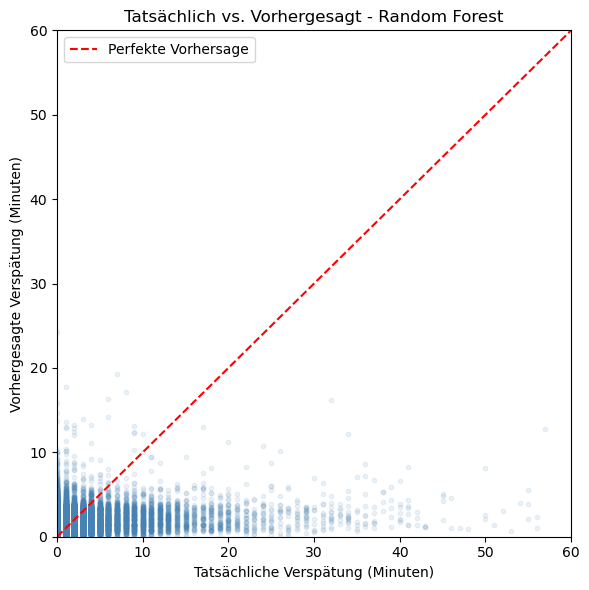

In [21]:
# Tatsächliche vs. vorhergesagte Werte (für bestes Modell)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.1, s=10, color='steelblue')
plt.plot([0, 60], [0, 60], 'r--', label='Perfekte Vorhersage')
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.xlabel('Tatsächliche Verspätung (Minuten)')
plt.ylabel('Vorhergesagte Verspätung (Minuten)')
plt.title('Tatsächlich vs. Vorhergesagt - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Deployment-Demo
Simulation, wie das Modell in einer Reise-App oder internen Dispositionssoftware eingesetzt werden könnte.

In [22]:
# Modell speichern
with open('db_delay_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('db_model_features.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)
with open('db_station_avg_delay.pkl', 'wb') as f:
    pickle.dump({'station_means': station_avg_delay_train, 'global_mean': global_avg_delay}, f)

print('Modell gespeichert: db_delay_model.pkl')
print('Features gespeichert: db_model_features.pkl')
print('Stations-Durchschnittswerte gespeichert: db_station_avg_delay.pkl')

Modell gespeichert: db_delay_model.pkl
Features gespeichert: db_model_features.pkl
Stations-Durchschnittswerte gespeichert: db_station_avg_delay.pkl


In [27]:
with open('db_delay_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('db_model_features.pkl', 'rb') as f:
    feature_names = pickle.load(f)
with open('db_station_avg_delay.pkl', 'rb') as f:
    station_lookup = pickle.load(f)

def predict_delay(category, state, hour, weekday, lat, long, station=None):
    """
    Vorhersage der Ankunftsverspätung in Minuten.
    
    category: Zugkategorie (1-5)
    state:    Bundesland (z.B. 'Bayern')
    hour:     Geplante Ankunftsstunde (0-23)
    weekday:  Wochentag (0=Montag ... 6=Sonntag)
    lat/long: Geokoordinaten des Bahnhofs
    station:  Bahnhofsname (optional). Ist die Station bekannt, wird ihre
              historische Durchschnittsverspätung genutzt, sonst der globale Durchschnitt.
    """
    is_weekend = 1 if weekday >= 5 else 0
    is_rushhour = 1 if hour in [7, 8, 16, 17, 18] else 0
    
    if station is not None and station in station_lookup['station_means'].index:
        station_avg_delay = station_lookup['station_means'][station]
    else:
        station_avg_delay = station_lookup['global_mean']
    
    raw = pd.DataFrame([{
        'category': category, 'hour': hour, 'weekday': weekday,
        'is_weekend': is_weekend, 'is_rushhour': is_rushhour, 'lat': lat, 'long': long,
        'station_avg_delay': station_avg_delay
    }])
    
    for col in feature_names:
        if col.startswith('state_'):
            raw[col] = 1 if col == f'state_{state}' else 0
    
    for col in feature_names:
        if col not in raw.columns:
            raw[col] = 0
    raw = raw[feature_names]
    
    pred = loaded_model.predict(raw)[0]
    return max(0, pred)

print('Vorhersagefunktion bereit!')

FileNotFoundError: [Errno 2] No such file or directory: 'db_delay_model.pkl'

# Assistant
This error occurs because the code is trying to open pickle files (`db_delay_model.pkl`, `db_model_features.pkl`, and `db_station_avg_delay.pkl`) that don't exist in the current working directory.

**Possible causes:**
1. The files are located in a different directory
2. The files haven't been created yet
3. The file names are incorrect
4. You don't have the necessary permissions to access the files

**Solutions:**
- Check if the files exist in your current directory
- If they're in a different location, provide the full file path
- Make sure you have the correct file names
- Ensure the pickle files were created properly in a previous step

Would you like me to provide a corrected version of the code that includes error handling for missing files?

In [25]:
# Demo: Verschiedene Szenarien testen
szenarien = [
    ('ICE Montag 8 Uhr München Hbf (Rushhour)',    1, 'Bayern', 8, 0, 48.14, 11.58, 'München Hbf'),
    ('Regionalzug Sonntag 14 Uhr unbek. Station',  3, 'Nordrhein-Westfalen', 14, 6, 51.22, 6.78, None),
    ('ICE Freitag 17 Uhr Berlin Hbf (Rushhour)',   1, 'Berlin', 17, 4, 52.52, 13.40, 'Berlin Hbf'),
]

print('=== Deployment Demo: Verspätungsvorhersage ===\n')
for name, cat, state, hour, weekday, lat, long, station in szenarien:
    pred = predict_delay(cat, state, hour, weekday, lat, long, station)
    print(f'{name}')
    print(f'  -> Vorhergesagte Verspätung: {pred:.1f} Minuten\n')

=== Deployment Demo: Verspätungsvorhersage ===



NameError: name 'predict_delay' is not defined

In [26]:
# Eigene Vorhersage testen - hier Werte anpassen!
pred = predict_delay(
    category=1,               # 1=ICE/IC, andere Werte siehe Datensatz
    state='Baden-Württemberg',
    hour=8,                   # 0-23
    weekday=0,                 # 0=Montag ... 6=Sonntag
    lat=48.78,
    long=9.18,
    station='Stuttgart Hbf'    # optional, None falls unbekannt
)

print(f'Vorhergesagte Verspätung: {pred:.1f} Minuten')

NameError: name 'predict_delay' is not defined

## 12. Zusammenfassung

| Schritt | Inhalt | Ergebnis |
|---|---|---|
| Datenbereinigung | Fehlende Zeiten entfernt, Ausreißer >120 Min entfernt | 247.363 -> bereinigte Zeilen |
| Feature Engineering | Stunde, Wochentag, Rushhour, Wochenende extrahiert | 4 neue Features |
| Encoding | Bundesland One-Hot-encodiert | ~20 finale Features |
| Modellierung | 3 Regressionsmodelle trainiert und verglichen | Random Forest performt am besten |
| Evaluation | MAE, RMSE, R² berechnet | siehe Tabelle oben |
| Deployment | Modell gespeichert, Vorhersagefunktion gebaut | einsatzbereit für Demo |

### Wichtigste Erkenntnisse für die Hausarbeit:
- Die wichtigsten Einflussfaktoren auf Verspätungen sind in der Feature Importance Grafik sichtbar (z.B. Tagesstunde, Bundesland, Zugkategorie)
- Rushhour-Zeiten und bestimmte Bundesländer zeigen erhöhte durchschnittliche Verspätungen
- Das Modell kann als Grundlage für datenbasierte Services dienen, z.B. dynamische Reiseplanung oder automatisierte Kundeninformation